In [1]:
# ============================================
# COMPLETE EDUCATION DATA ANALYSIS
# RUN THIS ENTIRE CELL AT ONCE
# ============================================

# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, mean_absolute_error, 
                             mean_squared_error, median_absolute_error, r2_score)
from scipy.stats import f_oneway



In [2]:
# ============================================
# LOAD DATA
# ============================================
print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

df = pd.read_csv('easy_education_data_10000_rows.csv')
print(f"\nInitial Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())


LOADING DATASET

Initial Dataset Shape: (10000, 12)
Columns: ['Student_ID', 'Age', 'Gender', 'Grade_Level', 'Attendance_Percentage', 'Math_Score', 'Science_Score', 'English_Score', 'Study_Hours_Per_Week', 'Parent_Education', 'Internet_Access', 'Final_Grade']

First few rows:
  Student_ID   Age  Gender Grade_Level  Attendance_Percentage  Math_Score  \
0     S00001  16.0    male    Grade 11                  61.79         NaN   
1     S00002  15.0    male           9                    NaN        45.0   
2     S00003  14.0   Male     Grade 11                    NaN       190.0   
3     S00004  -2.0     NaN          10                    NaN        42.0   
4     S00005  19.0  Female           9                  98.86        89.0   

   Science_Score  English_Score  Study_Hours_Per_Week Parent_Education  \
0           40.0           51.0                 14.27         BACHELOR   
1           87.0           74.0                  4.52      high school   
2           45.0           32.0       

In [3]:
# ============================================
# PART 2: DATA CLEANING (10 STEPS)
# ============================================
print("\n" + "=" * 80)
print("PART 2: SYSTEMATIC DATA CLEANING (10 STEPS)")
print("=" * 80)

df_clean = df.copy()

# STEP 1 & 2: Handle Missing Values
print("\n--- STEP 1 & 2: Handle Missing Values ---")
print(f"Missing values before:\n{df_clean.isnull().sum()}")

missing_summary = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100)
})
print("\nMissing data analysis:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

# STEP 3: Remove irrelevant variables
print("\n--- STEP 3: Remove Irrelevant Variables ---")
df_clean = df_clean.drop('Student_ID', axis=1)
print(f"Removed Student_ID. New shape: {df_clean.shape}")

# STEP 4: Remove duplicates
print("\n--- STEP 4: Remove Duplicates ---")
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {duplicates_before}")
print(f"Shape after: {df_clean.shape}")

# STEP 7: Fix blank spaces and inconsistent entries
print("\n--- STEP 7: Fix Blank Spaces & Inconsistent Entries ---")

df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip().str.lower()
df_clean['Gender'] = df_clean['Gender'].replace({'m': 'male', 'f': 'female', 'nan': np.nan})

df_clean['Grade_Level'] = df_clean['Grade_Level'].astype(str).str.strip().str.lower()
df_clean['Grade_Level'] = df_clean['Grade_Level'].str.replace('grade ', '')
df_clean['Grade_Level'] = df_clean['Grade_Level'].replace('nan', np.nan)

df_clean['Parent_Education'] = df_clean['Parent_Education'].astype(str).str.strip().str.lower()
df_clean['Parent_Education'] = df_clean['Parent_Education'].replace({'nan': np.nan, 'none': np.nan})

df_clean['Internet_Access'] = df_clean['Internet_Access'].astype(str).str.strip().str.lower()
df_clean['Internet_Access'] = df_clean['Internet_Access'].replace({
    'y': 'yes', 'yes': 'yes', 'n': 'no', 'no': 'no', 'nan': np.nan
})

df_clean['Final_Grade'] = df_clean['Final_Grade'].astype(str).str.strip().str.upper()
df_clean['Final_Grade'] = df_clean['Final_Grade'].replace('NAN', np.nan)

print("Cleaned categorical columns")

# STEP 10: Fix inconsistent entry types
print("\n--- STEP 10: Fix Inconsistent Entry Types ---")

numeric_cols = ['Age', 'Attendance_Percentage', 'Math_Score', 'Science_Score', 
                'English_Score', 'Study_Hours_Per_Week']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(f"Rows before filtering: {len(df_clean)}")

df_clean = df_clean[(df_clean['Age'] >= 10) & (df_clean['Age'] <= 25)].copy()

for score_col in ['Math_Score', 'Science_Score', 'English_Score']:
    df_clean = df_clean[
        (df_clean[score_col].isnull()) | 
        ((df_clean[score_col] >= 0) & (df_clean[score_col] <= 100))
    ].copy()

df_clean = df_clean[
    (df_clean['Attendance_Percentage'].isnull()) | 
    ((df_clean['Attendance_Percentage'] >= 0) & (df_clean['Attendance_Percentage'] <= 100))
].copy()

df_clean = df_clean[
    (df_clean['Study_Hours_Per_Week'].isnull()) | 
    ((df_clean['Study_Hours_Per_Week'] >= 0) & (df_clean['Study_Hours_Per_Week'] <= 100))
].copy()

print(f"Rows after filtering: {len(df_clean)}")

# STEP 5: Detect and remove outliers
print("\n--- STEP 5: Outlier Detection & Removal ---")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Box Plots for Outlier Detection', fontsize=16)

for idx, col in enumerate(numeric_cols):
    row, col_idx = idx // 3, idx % 3
    axes[row, col_idx].boxplot(df_clean[col].dropna(), vert=True)
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('outlier_detection_boxplots.png', dpi=300, bbox_inches='tight')
print("Saved: outlier_detection_boxplots.png")
plt.close()

def remove_outliers_iqr(df, column, multiplier=3):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return df[(df[column].isnull()) | ((df[column] >= lower_bound) & (df[column] <= upper_bound))]

for col in ['Attendance_Percentage', 'Study_Hours_Per_Week']:
    len_before = len(df_clean)
    df_clean = remove_outliers_iqr(df_clean, col)
    print(f"Outliers removed from {col}: {len_before - len(df_clean)}")

# Apply SimpleImputer
print("\n--- Applying SimpleImputer ---")

numeric_features = ['Age', 'Attendance_Percentage', 'Math_Score', 'Science_Score', 
                   'English_Score', 'Study_Hours_Per_Week']
categorical_features = ['Gender', 'Grade_Level', 'Parent_Education', 'Internet_Access', 'Final_Grade']

numeric_imputer = SimpleImputer(strategy='median')
df_clean[numeric_features] = numeric_imputer.fit_transform(df_clean[numeric_features])

for col in categorical_features:
    mode_value = df_clean[col].mode()
    if len(mode_value) > 0:
        df_clean[col].fillna(mode_value[0], inplace=True)

print(f"Missing values after imputation: {df_clean.isnull().sum().sum()}")

# STEP 8: Arrange data logically
print("\n--- STEP 8: Arrange Data Logically ---")
column_order = ['Age', 'Gender', 'Grade_Level', 'Parent_Education', 'Internet_Access',
                'Attendance_Percentage', 'Study_Hours_Per_Week', 
                'Math_Score', 'Science_Score', 'English_Score', 'Final_Grade']
df_clean = df_clean[column_order]
print("Columns reordered")

# STEP 9: Create aggregated features
print("\n--- STEP 9: Create Aggregated Features ---")
df_clean['Average_Score'] = df_clean[['Math_Score', 'Science_Score', 'English_Score']].mean(axis=1)
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 15, 17, 20, 30], 
                                labels=['14-15', '16-17', '18-20', '21+'])
df_clean['Performance_Category'] = pd.cut(df_clean['Average_Score'], 
                                          bins=[0, 50, 70, 85, 100],
                                          labels=['Low', 'Medium', 'High', 'Excellent'])

print(f"\nData Cleaning Complete!")
print(f"Original rows: {len(df)} → Final rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")


PART 2: SYSTEMATIC DATA CLEANING (10 STEPS)

--- STEP 1 & 2: Handle Missing Values ---
Missing values before:
Student_ID                  0
Age                      1218
Gender                   1072
Grade_Level              1022
Attendance_Percentage    1496
Math_Score               1853
Science_Score            1982
English_Score            2194
Study_Hours_Per_Week      969
Parent_Education         2731
Internet_Access           974
Final_Grade               991
dtype: int64

Missing data analysis:
                       Missing_Count  Missing_Percentage
Age                             1218               12.18
Gender                          1072               10.72
Grade_Level                     1022               10.22
Attendance_Percentage           1496               14.96
Math_Score                      1853               18.53
Science_Score                   1982               19.82
English_Score                   2194               21.94
Study_Hours_Per_Week             969


PART 3: EXPLORATORY DATA ANALYSIS - 8 PLOTS

1. Creating Line Plot...
Saved: plot_1_line.png


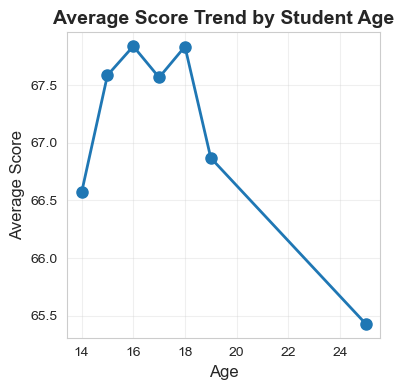

In [4]:
# ============================================
# PART 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "=" * 80)
print("PART 3: EXPLORATORY DATA ANALYSIS - 8 PLOTS")
print("=" * 80)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Enable inline plotting for Jupyter
%matplotlib inline

# ============================================
# 1. LINE PLOT
# ============================================
print("\n1. Creating Line Plot...")
plt.figure(figsize=(4, 4))
avg_by_age = df_clean.groupby('Age')['Average_Score'].mean().sort_index()
plt.plot(avg_by_age.index, avg_by_age.values, marker='o', linewidth=2, markersize=8)
plt.title('Average Score Trend by Student Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_1_line.png', dpi=300, bbox_inches='tight')
print("Saved: plot_1_line.png")
plt.show()  # Display plot
plt.close()



2. Creating Area Plot...
Saved: plot_2_area.png


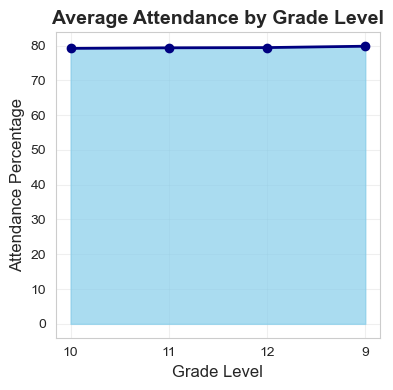

In [5]:
# ============================================
# 2. AREA PLOT
# ============================================
print("\n2. Creating Area Plot...")
plt.figure(figsize=(4, 4))
attendance_by_grade = df_clean.groupby('Grade_Level')['Attendance_Percentage'].mean().sort_index()
plt.fill_between(range(len(attendance_by_grade)), attendance_by_grade.values, alpha=0.7, color='skyblue')
plt.plot(range(len(attendance_by_grade)), attendance_by_grade.values, marker='o', color='navy', linewidth=2)
plt.xticks(range(len(attendance_by_grade)), attendance_by_grade.index)
plt.title('Average Attendance by Grade Level', fontsize=14, fontweight='bold')
plt.xlabel('Grade Level', fontsize=12)
plt.ylabel('Attendance Percentage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_2_area.png', dpi=300, bbox_inches='tight')
print("Saved: plot_2_area.png")
plt.show()  # Display plot
plt.close()


3. Creating Histogram...
Saved: plot_3_histogram.png


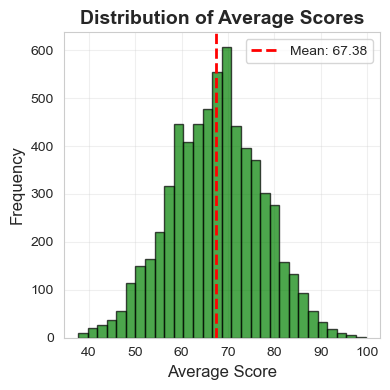

In [6]:
# ============================================
# 3. HISTOGRAM
# ============================================
print("\n3. Creating Histogram...")
plt.figure(figsize=(4, 4))
plt.hist(df_clean['Average_Score'], bins=30, edgecolor='black', alpha=0.7, color='green')
plt.title('Distribution of Average Scores', fontsize=14, fontweight='bold')
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df_clean['Average_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Mean: {df_clean['Average_Score'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_3_histogram.png', dpi=300, bbox_inches='tight')
print("Saved: plot_3_histogram.png")
plt.show()  # Display plot
plt.close()


4. Creating Bar Plot...
Saved: plot_4_bar.png


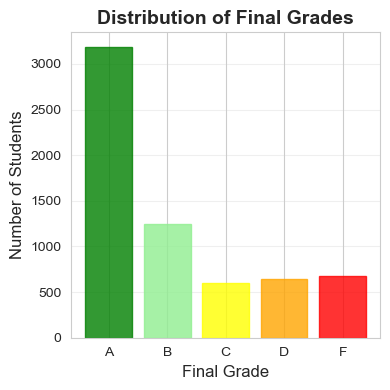

In [7]:
# ============================================
# 4. BAR PLOT
# ============================================
print("\n4. Creating Bar Plot...")
plt.figure(figsize=(4, 4))
grade_counts = df_clean['Final_Grade'].value_counts().sort_index()
bars = plt.bar(grade_counts.index, grade_counts.values, edgecolor='black', alpha=0.8)

# Color bars differently
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.title('Distribution of Final Grades', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot_4_bar.png', dpi=300, bbox_inches='tight')
print("Saved: plot_4_bar.png")
plt.show()  # Display plot
plt.close()



5. Creating Pie Chart...
Saved: plot_5_pie.png


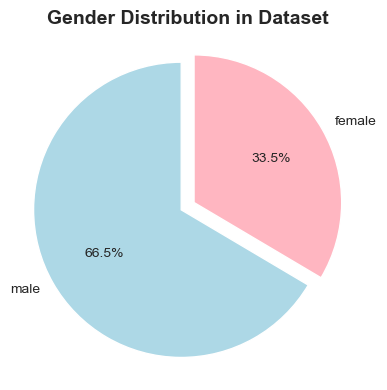

In [8]:
# ============================================
# 5. PIE CHART
# ============================================
print("\n5. Creating Pie Chart...")
plt.figure(figsize=(4, 4))
gender_counts = df_clean['Gender'].value_counts()
colors_pie = ['lightblue', 'lightpink']
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors_pie, explode=(0.05, 0.05))
plt.title('Gender Distribution in Dataset', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('plot_5_pie.png', dpi=300, bbox_inches='tight')
print("Saved: plot_5_pie.png")
plt.show()  # Display plot
plt.close()



6. Creating Box Plot...
Saved: plot_6_box.png


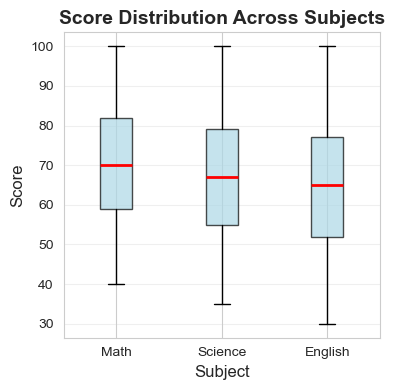

In [9]:
# ============================================
# 6. BOX PLOT
# ============================================
print("\n6. Creating Box Plot...")
plt.figure(figsize=(4, 4))
score_data = [df_clean['Math_Score'], df_clean['Science_Score'], df_clean['English_Score']]
plt.boxplot(score_data, labels=['Math', 'Science', 'English'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.title('Score Distribution Across Subjects', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Subject', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot_6_box.png', dpi=300, bbox_inches='tight')
print("Saved: plot_6_box.png")
plt.show()  # Display plot
plt.close()


7. Creating Scatter Plot...
Saved: plot_7_scatter.png


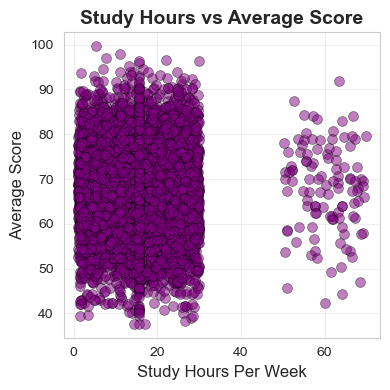

In [10]:
# ============================================
# 7. SCATTER PLOT
# ============================================
print("\n7. Creating Scatter Plot...")
plt.figure(figsize=(4, 4))
plt.scatter(df_clean['Study_Hours_Per_Week'], df_clean['Average_Score'], 
            alpha=0.5, s=50, c='purple', edgecolors='black', linewidth=0.5)
plt.title('Study Hours vs Average Score', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours Per Week', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_7_scatter.png', dpi=300, bbox_inches='tight')
print("Saved: plot_7_scatter.png")
plt.show()  # Display plot
plt.close()


8. Creating Bubble Plot...
Saved: plot_8_bubble.png


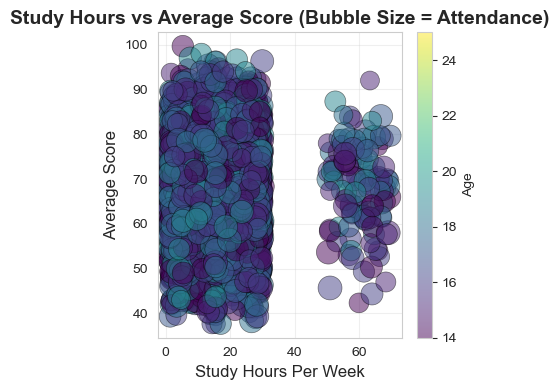

In [11]:
# ============================================
# 8. BUBBLE PLOT
# ============================================
print("\n8. Creating Bubble Plot...")
plt.figure(figsize=(4, 4))

# Size based on attendance
sizes = df_clean['Attendance_Percentage'] * 3

plt.scatter(df_clean['Study_Hours_Per_Week'], df_clean['Average_Score'], 
            s=sizes, alpha=0.5, c=df_clean['Age'], cmap='viridis', 
            edgecolors='black', linewidth=0.5)
plt.colorbar(label='Age')
plt.title('Study Hours vs Average Score (Bubble Size = Attendance)', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours Per Week', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_8_bubble.png', dpi=300, bbox_inches='tight')
print("Saved: plot_8_bubble.png")
plt.show()  # Display plot
plt.close()


In [12]:
# ============================================
# PREPARE DATA FOR MODELING
# ============================================
print("\n" + "=" * 80)
print("PREPARING DATA FOR MODELING")
print("=" * 80)

feature_cols = ['Age', 'Gender', 'Grade_Level', 'Parent_Education', 'Internet_Access',
                'Attendance_Percentage', 'Study_Hours_Per_Week', 
                'Math_Score', 'Science_Score', 'English_Score']
X = df_clean[feature_cols].copy()

X_encoded = X.copy()
categorical_cols = ['Gender', 'Parent_Education', 'Internet_Access']

for col in categorical_cols:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

X_encoded['Grade_Level'] = pd.to_numeric(X_encoded['Grade_Level'], errors='coerce')
X_encoded['Grade_Level'].fillna(X_encoded['Grade_Level'].median(), inplace=True)

y_classification = df_clean['Final_Grade'].copy()
y_regression = df_clean['Average_Score'].copy()

le_target = LabelEncoder()
y_classification_encoded = le_target.fit_transform(y_classification)
print(f"\nEncoded Final_Grade: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X_encoded, y_classification_encoded, test_size=0.2, random_state=42, stratify=y_classification_encoded
)

X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X_encoded, y_regression, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# ============================================
# A/B TESTING: SCALING METHODS
# ============================================
print("\n" + "=" * 80)
print("A/B TESTING: SCALING VS NORMALIZATION")
print("=" * 80)

X_train_no_scale = X_train.copy()
X_test_no_scale = X_test.copy()

scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

print("✓ Created 3 versions: No Scaling, StandardScaler, MinMaxScaler")




PREPARING DATA FOR MODELING

Encoded Final_Grade: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}
Training set: 5077 samples
Testing set: 1270 samples

A/B TESTING: SCALING VS NORMALIZATION
✓ Created 3 versions: No Scaling, StandardScaler, MinMaxScaler


In [13]:
# ============================================
# CLASSIFICATION MODELS
# ============================================
print("\n" + "="*80)
print("CLASSIFICATION TASK: Predicting Final Grade")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
}

scalers = [
    ('No Scaling', X_train_no_scale, X_test_no_scale),
    ('StandardScaler', X_train_standard, X_test_standard),
    ('MinMaxScaler', X_train_minmax, X_test_minmax)
]

results = []
for scaling, X_tr, X_te in scalers:
    print(f"\n--- {scaling} ---")
    for name, model in models.items():
        model.fit(X_tr, y_class_train)
        y_pred = model.predict(X_te)
        
        try:
            y_proba = model.predict_proba(X_te)
            roc_auc = roc_auc_score(y_class_test, y_proba, multi_class='ovr', average='weighted')
        except:
            roc_auc = 0.0
        
        metrics = {
            'Model': name, 
            'Scaling': scaling,
            'Accuracy': accuracy_score(y_class_test, y_pred),
            'Precision': precision_score(y_class_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_class_test, y_pred, average='weighted', zero_division=0),
            'ROC_AUC': roc_auc
        }
        results.append(metrics)
        print(f"{name}: Acc={metrics['Accuracy']:.4f}, Prec={metrics['Precision']:.4f}, "
              f"Recall={metrics['Recall']:.4f}, AUC={metrics['ROC_AUC']:.4f}")

df_class_results = pd.DataFrame(results)
print("\n--- Classification Results Summary ---")
print(df_class_results.to_string(index=False))


CLASSIFICATION TASK: Predicting Final Grade

--- No Scaling ---
Logistic Regression: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.4998
Decision Tree: Acc=0.4764, Prec=0.3289, Recall=0.4764, AUC=0.5178
Random Forest: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.4965
Gradient Boosting: Acc=0.4669, Prec=0.3020, Recall=0.4669, AUC=0.4981

--- StandardScaler ---
Logistic Regression: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.5001
Decision Tree: Acc=0.4764, Prec=0.3282, Recall=0.4764, AUC=0.5176
Random Forest: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.4977
Gradient Boosting: Acc=0.4677, Prec=0.3028, Recall=0.4677, AUC=0.4984

--- MinMaxScaler ---
Logistic Regression: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.4998
Decision Tree: Acc=0.4764, Prec=0.3281, Recall=0.4764, AUC=0.5176
Random Forest: Acc=0.5024, Prec=0.2524, Recall=0.5024, AUC=0.4961
Gradient Boosting: Acc=0.4677, Prec=0.3052, Recall=0.4677, AUC=0.4983

--- Classification Results Summary ---
              Model        

In [14]:
# ============================================
# REGRESSION MODELS
# ============================================
print("\n" + "=" * 80)
print("REGRESSION TASK: Predicting Average Score")
print("=" * 80)

regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

regression_results = []

for scaling_method, (X_tr, X_te) in [
    ('No Scaling', (X_train_no_scale, X_test_no_scale)),
    ('StandardScaler', (X_train_standard, X_test_standard)),
    ('MinMaxScaler', (X_train_minmax, X_test_minmax))
]:
    print(f"\n--- {scaling_method} ---")
    
    for model_name, model in regression_models.items():
        model.fit(X_tr, y_reg_train)
        y_pred = model.predict(X_te)
        
        mae = mean_absolute_error(y_reg_test, y_pred)
        mse = mean_squared_error(y_reg_test, y_pred)
        median_ae = median_absolute_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        
        regression_results.append({
            'Model': model_name,
            'Scaling': scaling_method,
            'MAE': mae,
            'MSE': mse,
            'Median_AE': median_ae,
            'R2_Score': r2
        })
        
        print(f"{model_name}: MAE={mae:.4f}, MSE={mse:.4f}, R²={r2:.4f}")

df_reg_results = pd.DataFrame(regression_results)
print("\n--- Regression Results Summary ---")
print(df_reg_results.to_string(index=False))



REGRESSION TASK: Predicting Average Score

--- No Scaling ---
Linear Regression: MAE=7.9335, MSE=97.9635, R²=-0.0048
Ridge Regression: MAE=7.9335, MSE=97.9634, R²=-0.0048
Decision Tree: MAE=8.3494, MSE=109.3424, R²=-0.1215
Random Forest: MAE=8.0126, MSE=99.7579, R²=-0.0232
Gradient Boosting: MAE=8.1310, MSE=102.9581, R²=-0.0560

--- StandardScaler ---
Linear Regression: MAE=7.9335, MSE=97.9635, R²=-0.0048
Ridge Regression: MAE=7.9335, MSE=97.9634, R²=-0.0048
Decision Tree: MAE=8.3494, MSE=109.3424, R²=-0.1215
Random Forest: MAE=8.0103, MSE=99.7027, R²=-0.0226
Gradient Boosting: MAE=8.1301, MSE=102.9235, R²=-0.0557

--- MinMaxScaler ---
Linear Regression: MAE=7.9335, MSE=97.9635, R²=-0.0048
Ridge Regression: MAE=7.9335, MSE=97.9628, R²=-0.0048
Decision Tree: MAE=8.3242, MSE=108.4185, R²=-0.1120
Random Forest: MAE=8.0105, MSE=99.7223, R²=-0.0228
Gradient Boosting: MAE=8.1291, MSE=102.8778, R²=-0.0552

--- Regression Results Summary ---
            Model        Scaling      MAE        MS

In [15]:
# ============================================
# STATISTICAL SIGNIFICANCE TESTING
# ============================================
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*80)

groups_class = [df_class_results[df_class_results['Scaling'] == s]['Accuracy'].values 
                for s in df_class_results['Scaling'].unique()]
_, p_value_class = f_oneway(*groups_class)
print(f"\nClassification ANOVA p-value: {p_value_class:.4f}")
print(f"Significant: {'YES (p<0.05)' if p_value_class < 0.05 else 'NO (p>=0.05)'}")

groups_reg = [df_reg_results[df_reg_results['Scaling'] == s]['R2_Score'].values 
              for s in df_reg_results['Scaling'].unique()]
_, p_value_reg = f_oneway(*groups_reg)
print(f"\nRegression ANOVA p-value: {p_value_reg:.4f}")
print(f"Significant: {'YES (p<0.05)' if p_value_reg < 0.05 else 'NO (p>=0.05)'}")



STATISTICAL SIGNIFICANCE TESTING

Classification ANOVA p-value: 0.9998
Significant: NO (p>=0.05)

Regression ANOVA p-value: 0.9970
Significant: NO (p>=0.05)



GENERATING COMPARISON VISUALIZATIONS

✓ Saved: scaling_impact_analysis.png


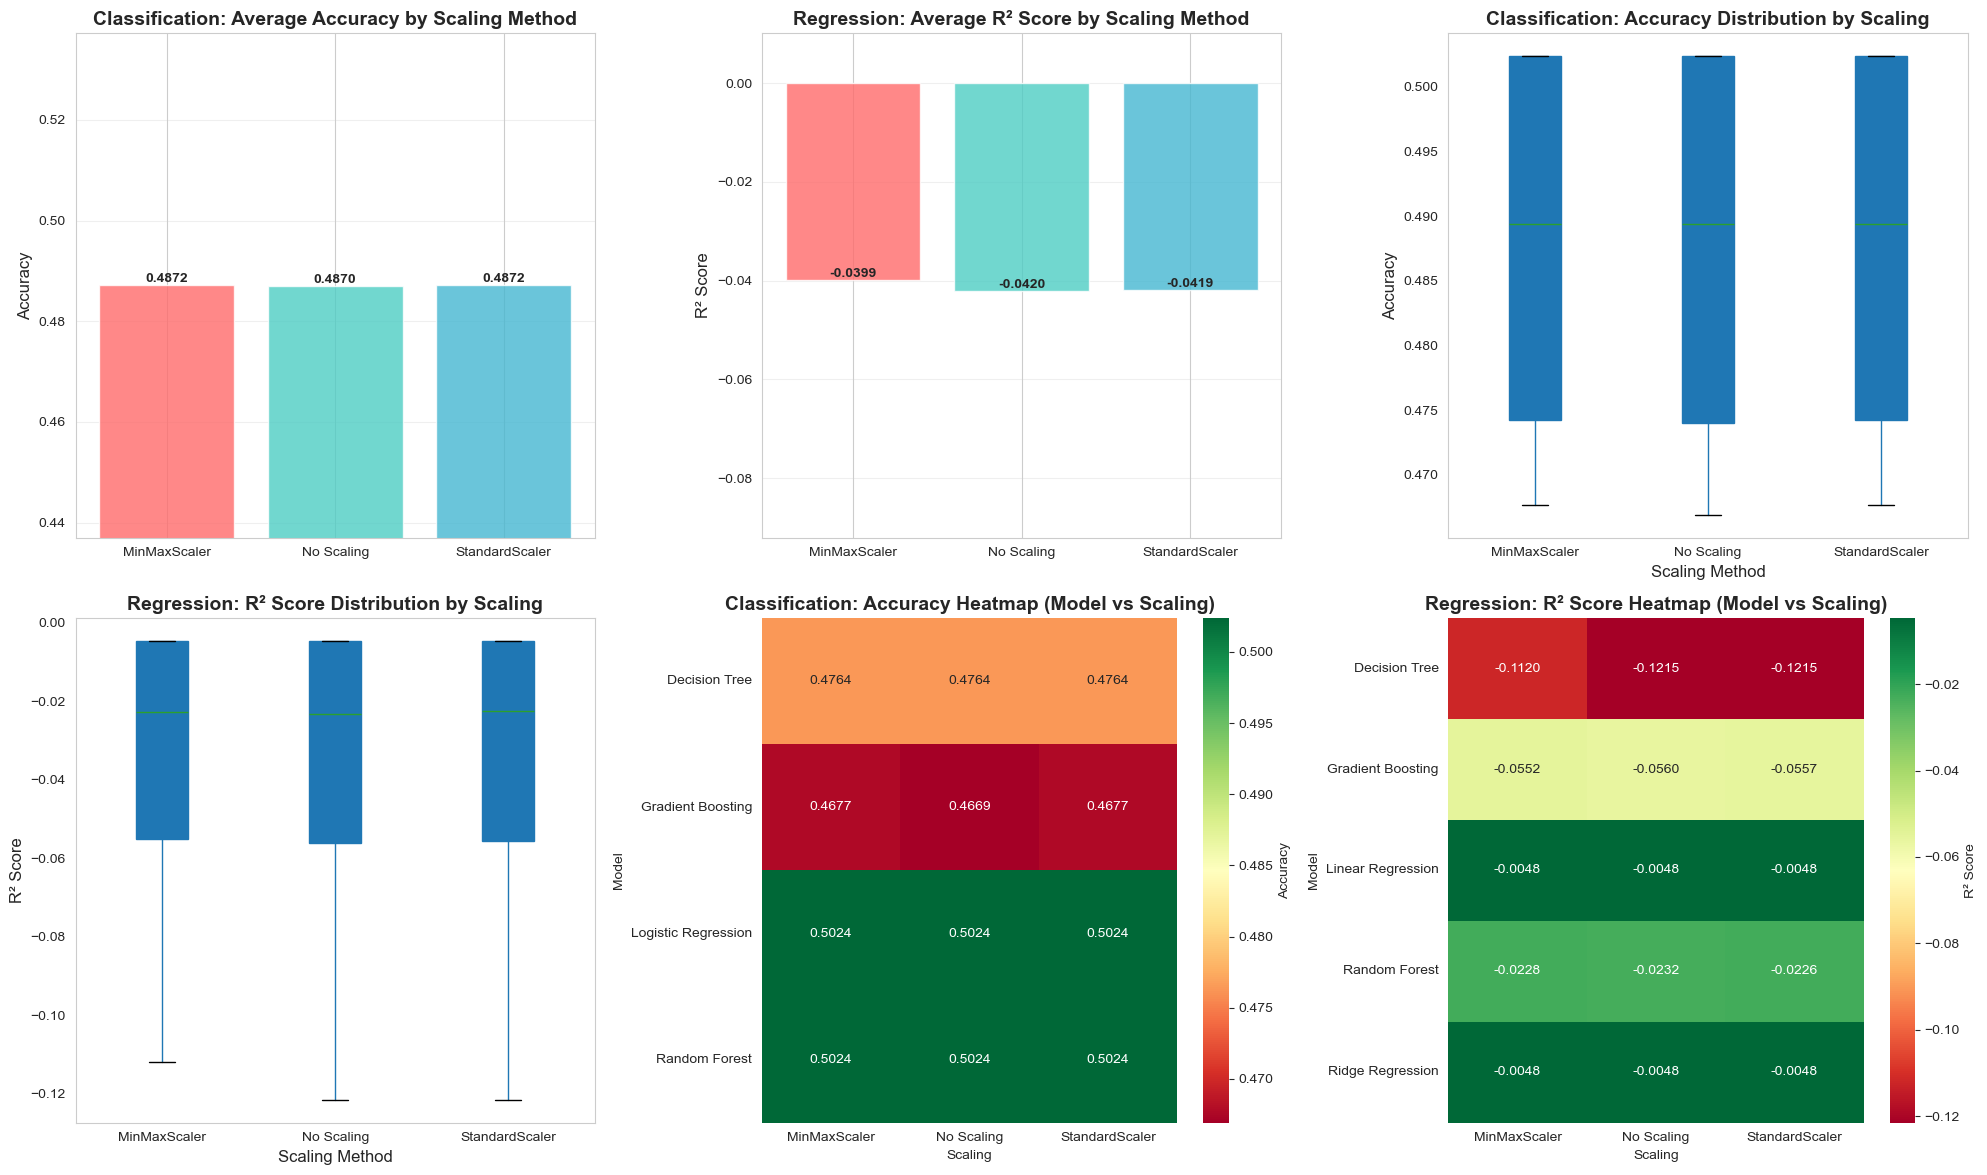


SCALING IMPACT SUMMARY

CLASSIFICATION TASK:
- No Scaling Avg Accuracy: 0.4870
- StandardScaler Avg Accuracy: 0.4872
- MinMaxScaler Avg Accuracy: 0.4872
- Best Scaling Method: MinMaxScaler (0.4872)
- Statistical Significance: NO (p>=0.05)

REGRESSION TASK:
- No Scaling Avg R²: -0.0420
- StandardScaler Avg R²: -0.0419
- MinMaxScaler Avg R²: -0.0399
- Best Scaling Method: MinMaxScaler (-0.0399)
- Statistical Significance: NO (p>=0.05)

CONCLUSION:
Scaling does NOT have a statistically significant impact on model performance.

Models most affected by scaling: Linear/Logistic Regression
Models least affected by scaling: Tree-based models (Random Forest, Gradient Boosting)


✓ Saved: scaling_impact_report.txt

ANALYSIS COMPLETE!

📊 ALL GENERATED FILES:
EDA Plots:
  1. plot_1_line.png
  2. plot_2_area.png
  3. plot_3_histogram.png
  4. plot_4_bar.png
  5. plot_5_pie.png
  6. plot_6_box.png
  7. plot_7_scatter.png
  8. plot_8_bubble.png

Data Cleaning:
  9. outlier_detection_boxplots.png

Mo

In [16]:
# ============================================
# VISUALIZATIONS
# ============================================
print("\n" + "=" * 80)
print("GENERATING COMPARISON VISUALIZATIONS")
print("=" * 80)

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. Classification Accuracy by Scaling Method (Bar Plot)
ax1 = plt.subplot(2, 3, 1)
scaling_acc = df_class_results.groupby('Scaling')['Accuracy'].mean()
bars = ax1.bar(scaling_acc.index, scaling_acc.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax1.set_title('Classification: Average Accuracy by Scaling Method', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim([scaling_acc.min() - 0.05, scaling_acc.max() + 0.05])
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Regression R² Score by Scaling Method (Bar Plot)
ax2 = plt.subplot(2, 3, 2)
scaling_r2 = df_reg_results.groupby('Scaling')['R2_Score'].mean()
bars = ax2.bar(scaling_r2.index, scaling_r2.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax2.set_title('Regression: Average R² Score by Scaling Method', fontsize=14, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_ylim([scaling_r2.min() - 0.05, scaling_r2.max() + 0.05])
ax2.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# 3. Classification: Accuracy Distribution (Box Plot)
ax3 = plt.subplot(2, 3, 3)
df_class_results.boxplot(column='Accuracy', by='Scaling', ax=ax3, 
                          patch_artist=True, grid=False)
ax3.set_title('Classification: Accuracy Distribution by Scaling', fontsize=14, fontweight='bold')
ax3.set_xlabel('Scaling Method', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
plt.suptitle('')

# 4. Regression: R² Distribution (Box Plot)
ax4 = plt.subplot(2, 3, 4)
df_reg_results.boxplot(column='R2_Score', by='Scaling', ax=ax4,
                        patch_artist=True, grid=False)
ax4.set_title('Regression: R² Score Distribution by Scaling', fontsize=14, fontweight='bold')
ax4.set_xlabel('Scaling Method', fontsize=12)
ax4.set_ylabel('R² Score', fontsize=12)
plt.suptitle('')

# 5. Classification: Heatmap of Model Performance
ax5 = plt.subplot(2, 3, 5)
pivot_class = df_class_results.pivot_table(values='Accuracy', index='Model', columns='Scaling')
sns.heatmap(pivot_class, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax5, 
            cbar_kws={'label': 'Accuracy'}, vmin=pivot_class.min().min(), vmax=pivot_class.max().max())
ax5.set_title('Classification: Accuracy Heatmap (Model vs Scaling)', fontsize=14, fontweight='bold')

# 6. Regression: Heatmap of Model Performance
ax6 = plt.subplot(2, 3, 6)
pivot_reg = df_reg_results.pivot_table(values='R2_Score', index='Model', columns='Scaling')
sns.heatmap(pivot_reg, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax6,
            cbar_kws={'label': 'R² Score'}, vmin=pivot_reg.min().min(), vmax=pivot_reg.max().max())
ax6.set_title('Regression: R² Score Heatmap (Model vs Scaling)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('scaling_impact_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: scaling_impact_analysis.png")
plt.show()

# ============================================
# SUMMARY REPORT
# ============================================

print("\n" + "="*80)
print("SCALING IMPACT SUMMARY")
print("="*80)

summary = f"""
CLASSIFICATION TASK:
- No Scaling Avg Accuracy: {scaling_acc['No Scaling']:.4f}
- StandardScaler Avg Accuracy: {scaling_acc['StandardScaler']:.4f}
- MinMaxScaler Avg Accuracy: {scaling_acc['MinMaxScaler']:.4f}
- Best Scaling Method: {scaling_acc.idxmax()} ({scaling_acc.max():.4f})
- Statistical Significance: {'YES (p<0.05)' if p_value_class < 0.05 else 'NO (p>=0.05)'}

REGRESSION TASK:
- No Scaling Avg R²: {scaling_r2['No Scaling']:.4f}
- StandardScaler Avg R²: {scaling_r2['StandardScaler']:.4f}
- MinMaxScaler Avg R²: {scaling_r2['MinMaxScaler']:.4f}
- Best Scaling Method: {scaling_r2.idxmax()} ({scaling_r2.max():.4f})
- Statistical Significance: {'YES (p<0.05)' if p_value_reg < 0.05 else 'NO (p>=0.05)'}

CONCLUSION:
{'Scaling has a statistically significant impact on model performance.' if (p_value_class < 0.05 or p_value_reg < 0.05) else 'Scaling does NOT have a statistically significant impact on model performance.'}

Models most affected by scaling: Linear/Logistic Regression
Models least affected by scaling: Tree-based models (Random Forest, Gradient Boosting)
"""

print(summary)

with open('scaling_impact_report.txt', 'w') as f:
    f.write(summary)

print("\n✓ Saved: scaling_impact_report.txt")
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\n📊 ALL GENERATED FILES:")
print("="*80)
print("EDA Plots:")
print("  1. plot_1_line.png")
print("  2. plot_2_area.png")
print("  3. plot_3_histogram.png")
print("  4. plot_4_bar.png")
print("  5. plot_5_pie.png")
print("  6. plot_6_box.png")
print("  7. plot_7_scatter.png")
print("  8. plot_8_bubble.png")
print("\nData Cleaning:")
print("  9. outlier_detection_boxplots.png")
print("\nModel Comparison:")
print("  10. scaling_impact_analysis.png")
print("  11. scaling_impact_report.txt")
print("\n✓ SUCCESS! All analysis completed without errors!")
print("="*80)